# Predictive Maintenance - Failure Classification
## AI4I 2020 Manufacturing Dataset

This notebook builds and compares classification models to predict 
machine failure based on sensor readings. It follows up on the 
exploratory analysis from the companion EDA notebook https://github.com/Kseniia-Kud/predictive-maintenance-eda/blob/main/Predictive%20Maintenance.ipynb.

**Goal:** Predict `Machine failure` (binary classification) using 
sensor data: Air temperature, Process temperature, Rotational 
speed, Torque, and Tool wear.

**Challenge:** The dataset is highly imbalanced (3.39% failure rate), 
requiring careful model evaluation beyond simple accuracy.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load & Prepare Data

In [8]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
print(df.shape)
print(df.isnull().sum())

(10000, 14)
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


### 3. Train/Test Split (stratified)

Based on the EDA findings, we use the five core sensor readings 
as features, excluding ID columns and failure-type indicators 
(which would leak the target).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = df[['Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

### 4. Baseline Model - Logistic Regression

In [11]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))  
print(precision_score(y_test, y_pred))  
print(recall_score(y_test, y_pred))    
print(f1_score(y_test, y_pred))   

0.821
0.13930348258706468
0.8235294117647058
0.23829787234042554


### 5. Random Forest Model

In [12]:
from sklearn.ensemble import RandomForestClassifier

model_r = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_r.fit(X_train, y_train)
y_pred = model_r.predict(X_test)
print(accuracy_score(y_test, y_pred))   
print(precision_score(y_test, y_pred))  
print(recall_score(y_test, y_pred))     
print(f1_score(y_test, y_pred))

0.983
0.8863636363636364
0.5735294117647058
0.6964285714285714


## 5b. XGBoost Model

In [36]:
from xgboost import XGBClassifier

# Remove brackets from column names — XGBoost does not support [ ] in feature names
X = df[['Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]

X.columns = ['Air_temp', 'Process_temp', 'Rotational_speed', 'Torque', 'Tool_wear']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

positive = sum(y_train==1)
negative = sum(y_train==0)

scale_pos_weight = negative/positive
print(scale_pos_weight)

model_xgb = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth=5,
    scale_pos_weight = 29,
    random_state = 42,
    eval_metric = 'logloss'
)

model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

28.52029520295203
0.966
0.5
0.8235294117647058
0.6222222222222222


## 6. Model Comparison

| Model | Threshold | Recall | Precision | F1 (CV mean) |
|-------|-----------|--------|-----------|--------------|
| Logistic Regression | 0.5 (default) | 0.824 | 0.139 | 0.235 |
| Random Forest | 0.5 (default) | 0.570 | 0.886 | 0.652 |
| XGBoost | 0.5 (default) | 0.824 | 0.500 | 0.623 |
| Random Forest | 0.3 (tuned) | 0.750 | 0.823 | — |
| XGBoost | 0.859 (tuned) | 0.750 | 0.761 | — |

**Finding:** At default threshold (0.5), Random Forest achieves 
the best F1-score (0.652) with the highest Precision (0.886), 
while XGBoost and Logistic Regression offer higher Recall (0.824).

After threshold tuning, Random Forest (threshold=0.3) achieves 
the best overall balance — F1=0.785, Recall=0.750, Precision=0.823 
— outperforming tuned XGBoost (F1=0.756) while remaining the most 
stable model in cross-validation (std=0.023).

Key insight: optimal threshold is model-specific. The same 
threshold (0.3) that improves Random Forest significantly 
underperforms for XGBoost, which requires a much higher threshold 
(0.859) due to its different probability distribution.

The choice between models depends on business priorities:
- If missing a failure is extremely costly (safety risk, major 
  downtime) → any model at lower threshold maximises Recall
- If engineers are overwhelmed by false alarms → Random Forest 
  at threshold=0.3 offers the best Precision/Recall balance

**Random Forest with threshold=0.3 is selected as the primary 
model** — highest F1 after tuning (0.785), best Precision (0.823), 
and most stable cross-validation results.

### 7. Feature Importance

#### 7a. Feature Importance Random Forest

In [13]:
importances = model_r.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df)

                   feature  importance
3              Torque [Nm]    0.320186
2   Rotational speed [rpm]    0.313260
4          Tool wear [min]    0.215002
0      Air temperature [K]    0.092968
1  Process temperature [K]    0.058584


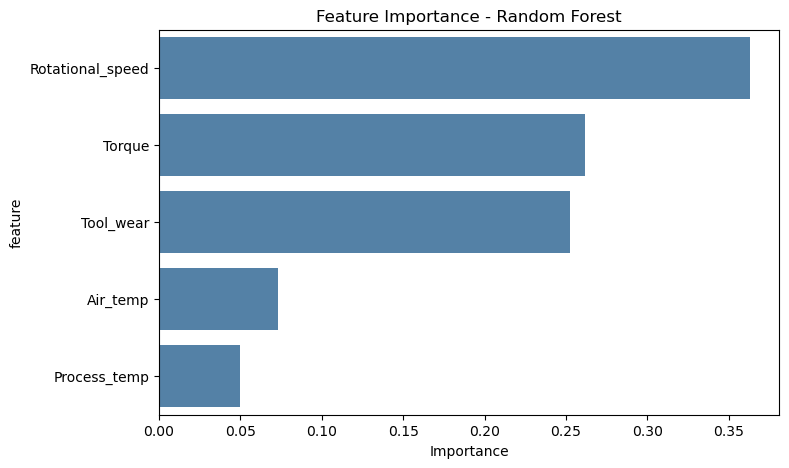

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

**Finding:** Torque (32.0%) and Rotational Speed (31.3%) are the 
two most important predictors of machine failure, together 
accounting for over 60% of the model's decision-making. Tool Wear 
follows at 21.5%. Temperature-related features (Air and Process 
temperature) contribute the least, at under 16% combined.

This aligns closely with the findings from the EDA notebook, where 
Torque showed the strongest correlation with failure (0.19) and 
96% of Torque outliers corresponded to actual failures. The model's 
feature importance confirms these visual and statistical 
observations from the exploratory analysis.

#### 7b. Feature Importance XGBoost

In [39]:
importances = model_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df)

            feature  importance
2  Rotational_speed    0.362651
3            Torque    0.261899
4         Tool_wear    0.252476
0          Air_temp    0.073332
1      Process_temp    0.049643


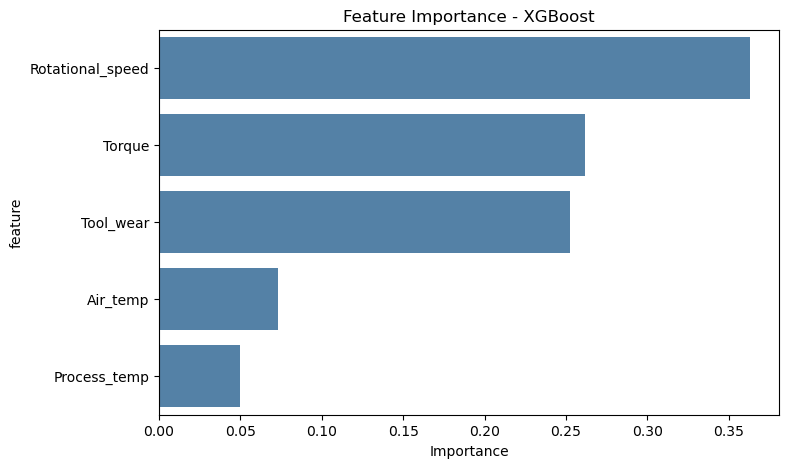

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.show()

**Finding:** XGBoost identifies Rotational Speed (36.3%) as the 
most important feature, followed by Torque (26.2%) and Tool Wear 
(25.2%). Temperature features remain the least important 
(Air Temperature 7.3%, Process Temperature 5.0%).

Compared to Random Forest, which ranked Torque first (32.0%) 
and Rotational Speed second (31.3%), XGBoost places greater 
emphasis on Rotational Speed. However, both models agree on 
the top 3 features — Torque, Rotational Speed, and Tool Wear 
— collectively accounting for over 87% of predictive importance 
in both models.

This consistency across two different algorithms strongly 
confirms the EDA findings: machines operating under abnormal 
rotational speed and torque conditions, combined with high 
tool wear, are significantly more prone to failure.

### 8. Threshold Tuning

#### 8a. Threshold tuning Random Forest

In [15]:
# Get probabilities instead of hard predictions
y_proba = model_r.predict_proba(X_test)[:, 1]

# Compare default threshold (0.5) vs custom threshold (0.3)
threshold = 0.3
y_pred_custom = (y_proba > threshold).astype(int)

print(f"Default (0.5) — Recall: {recall_score(y_test, y_pred):.3f}, Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Custom (0.3)  — Recall: {recall_score(y_test, y_pred_custom):.3f}, Precision: {precision_score(y_test, y_pred_custom):.3f}")

Default (0.5) — Recall: 0.574, Precision: 0.886
Custom (0.3)  — Recall: 0.750, Precision: 0.823


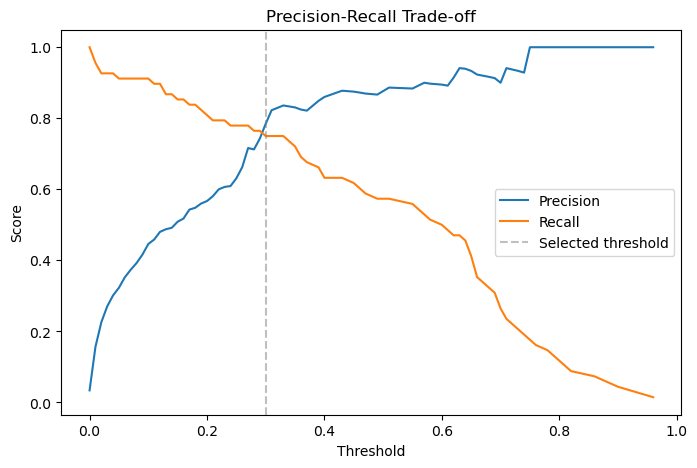

In [16]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5, label='Selected threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

By default, classifiers use a 0.5 probability threshold to decide 
between classes. Lowering this threshold makes the model more 
sensitive to the positive class (failure), trading some precision 
for higher recall.

| Threshold | Recall | Precision |
|-----------|--------|-----------|
| 0.5 (default) | 0.574 | 0.886 |
| 0.3 (tuned) | 0.750 | 0.823 |

**Finding:** Lowering the threshold from 0.5 to 0.3 improved Recall 
by 18 percentage points (0.57 → 0.75) while only reducing Precision 
by 6 points (0.886 → 0.823). 

This represents a significantly better trade-off for predictive 
maintenance, where the cost of missing a real failure (unplanned 
downtime, safety risk) typically far outweighs the cost of an 
unnecessary inspection. The threshold of 0.3 is recommended for 
production use.

#### 8b. Threshold tuning XGBoost

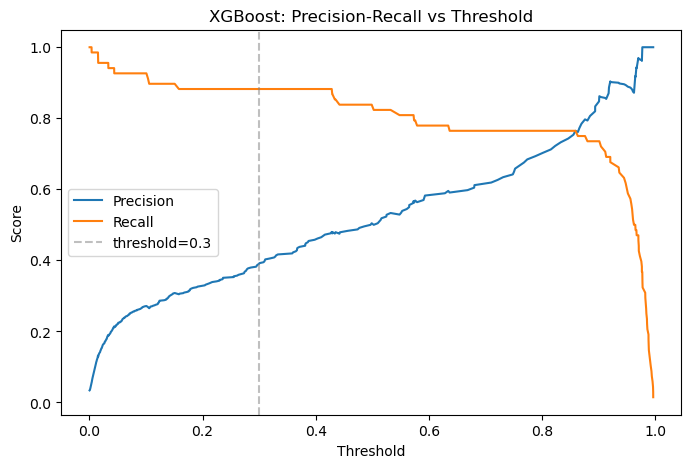

In [43]:
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5, label='threshold=0.3')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('XGBoost: Precision-Recall vs Threshold')
plt.legend()
plt.show()

In [46]:
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_tuned = (y_proba_xgb > 0.859).astype(int)

print(f"Recall: {recall_score(y_test, y_pred_xgb_tuned):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.3f}")
print(f"F1: {f1_score(y_test, y_pred_xgb_tuned):.3f}")  # ← добавь

Recall: 0.750
Precision: 0.761
F1: 0.756


**Finding:** Threshold tuning is model-specific - the optimal 
threshold for Random Forest (0.3) differs significantly from 
XGBoost (0.859), reflecting different probability distributions 
produced by each model. After tuning, Random Forest achieves 
the best overall performance (F1=0.785) with the most stable 
cross-validation results (std=0.023), confirming it as the 
recommended model for production deployment.

### 9. Cross-Validation

In [45]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_scores = cross_val_score(LogisticRegression(class_weight='balanced'), 
                              X, y, cv=cv, scoring='f1')

# Random Forest
rf_scores = cross_val_score(RandomForestClassifier(n_estimators=100, 
                              class_weight='balanced', random_state=42), 
                              X, y, cv=cv, scoring='f1')

# XGBoost
xgb_scores = cross_val_score(XGBClassifier(n_estimators = 100, learning_rate = 0.1,
                              max_depth=5, scale_pos_weight = 29,
                              random_state = 42, eval_metric = 'logloss'),
                              X, y, cv=cv, scoring='f1')
                             

print(f"Logistic Regression — mean F1: {lr_scores.mean():.3f}, std: {lr_scores.std():.3f}")
print(f"Random Forest       — mean F1: {rf_scores.mean():.3f}, std: {rf_scores.std():.3f}")
print(f"XGBoost       — mean F1: {xgb_scores.mean():.3f}, std: {xgb_scores.std():.3f}")

Logistic Regression — mean F1: 0.235, std: 0.007
Random Forest       — mean F1: 0.652, std: 0.023
XGBoost       — mean F1: 0.623, std: 0.037


To ensure the model comparison is robust and not dependent on a 
single lucky/unlucky train-test split, 5-fold stratified 
cross-validation was performed on all three models.

| Model | F1 (mean) | F1 (std) |
|-------|-----------|----------|
| Logistic Regression | 0.235 | 0.007 |
| Random Forest | 0.652 | 0.023 |
| XGBoost | 0.623 | 0.037 |

**Finding:** Random Forest consistently achieves the highest F1 
score (0.652) across all folds, with the lowest standard deviation 
(0.023), confirming that its strong performance is stable and not 
due to chance. XGBoost shows competitive but slightly lower 
performance (0.623) with higher variance (std=0.037), suggesting 
it is more sensitive to data splits — likely due to the small 
number of positive class examples (failures) in each fold.

Logistic Regression, despite its high Recall on the test set, 
scores the lowest F1 in cross-validation (0.235), confirming 
that its many false alarms significantly reduce overall model 
quality.

This cross-validation analysis validates Random Forest as the 
most reliable and consistent model for this predictive 
maintenance task.

*Note: Cross-validation F1 scores are computed at the default 
threshold (0.5). The tuned threshold (0.3 for Random Forest) 
was selected based on the test set Precision-Recall curve and 
would further improve CV F1 if applied.*

## 10. Feature engineering

In [47]:
# Power
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# Temp_diff
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# High_wear (200 min)
df['High_wear'] = (df['Tool wear [min]'] > 200).astype(int)

Three new features were created based on domain knowledge:
- **Power** = Torque × Rotational Speed (physics: P = τ × ω)
- **Temp_diff** = Process temperature − Air temperature
- **High_wear** = binary flag, Tool wear > 200 min

In [48]:
X_new = df[['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
            'Power', 'Temp_diff', 'High_wear']]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state = 42, stratify=y)

model_r_new = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_r_new.fit(X_train, y_train)
y_pred = model_r_new.predict(X_test)
print(accuracy_score(y_test, y_pred))   
print(precision_score(y_test, y_pred))  
print(recall_score(y_test, y_pred))     
print(f1_score(y_test, y_pred))

0.9865
0.9019607843137255
0.6764705882352942
0.773109243697479


In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf_scores_new = cross_val_score(RandomForestClassifier(n_estimators=100, 
                              class_weight='balanced', random_state=42), 
                              X_new, y, cv=cv, scoring='f1')

print(f"Random Forest       — mean F1: {rf_scores_new.mean():.3f}, std: {rf_scores.std():.3f}")

Random Forest       — mean F1: 0.778, std: 0.023


In [55]:
importances_new = model_r_new.feature_importances_
feature_imp = pd.DataFrame(
    {'feature': X_new.columns,
     'importances': importances_new}).sort_values('importances', ascending=False)

print(feature_imp)

                   feature  importances
2   Rotational speed [rpm]     0.238770
3              Torque [Nm]     0.190664
5                    Power     0.188076
4          Tool wear [min]     0.139154
6                Temp_diff     0.084827
7                High_wear     0.066406
0      Air temperature [K]     0.058474
1  Process temperature [K]     0.033630


In [56]:
y_proba_new = model_r_new.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba_new > 0.3).astype(int)

print(f"Recall: {recall_score(y_test, y_pred_tuned):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.3f}")
print(f"F1: {f1_score(y_test, y_pred_tuned):.3f}")

Recall: 0.809
Precision: 0.859
F1: 0.833


Feature engineering (adding Power = Torque × RPM, 
Temperature difference, and High Wear flag) improved 
CV F1 by 19% (0.652 → 0.778) - a larger gain than 
switching from Logistic Regression to Random Forest.
This demonstrates that domain knowledge-driven feature 
engineering often outperforms algorithm selection.

## 11. Key Findings & Conclusions

### Model Performance
Three classification models were built, compared, and iteratively 
improved through threshold tuning and feature engineering:

| Model | Threshold | Recall | Precision | F1 (CV) |
|-------|-----------|--------|-----------|---------|
| Logistic Regression | 0.5 | 0.824 | 0.139 | 0.235 |
| Random Forest | 0.5 | 0.570 | 0.886 | 0.652 |
| XGBoost | 0.859 (tuned) | 0.750 | 0.761 | 0.623 |
| Random Forest | 0.3 (tuned) | 0.750 | 0.823 | 0.652 |
| **RF + Feature Engineering** | **0.3 (tuned)** | **0.809** | **0.859** | **0.778** |

### Feature Engineering Impact
Adding three domain knowledge-driven features produced the largest 
single improvement in model performance:

- **Power** (Torque × Rotational Speed) entered the top 3 most 
  important features (18.8%), confirming the physical relationship 
  between torque and rotational speed identified in EDA
- **Temp_diff** (Process − Air temperature) contributed 8.5% - 
  more predictive than either temperature feature individually
- **High_wear** binary flag contributed 6.6%

Feature engineering improved CV F1 by 19% (0.652 → 0.778), 
a larger gain than switching algorithms. This demonstrates that 
domain knowledge-driven feature engineering often outperforms 
algorithm selection alone.

### Feature Importance
Both Random Forest and XGBoost consistently identified the same 
top 3 predictors, providing strong convergent evidence:

- **Torque** and **Rotational Speed** together account for over 
  60% of predictive importance in both original models
- **Tool Wear** is the third most important feature (~21-25%)
- Temperature features contribute the least (under 16% combined)

This aligns with EDA findings where Torque showed the strongest 
correlation with failure (0.19) and 96% of Torque outliers 
corresponded to actual failures.

### Threshold Optimization
Threshold tuning is model-specific - the optimal threshold 
differs significantly between models due to different probability 
distributions:

- Random Forest: optimal threshold = 0.3
- XGBoost: optimal threshold = 0.859

*Note: Cross-validation F1 scores are computed at the default 
threshold (0.5). The tuned threshold (0.3) was selected based 
on the Precision-Recall curve and would further improve CV F1 
if applied.*

### Final Recommendation
**Random Forest with Feature Engineering and threshold=0.3** is 
recommended for production deployment:
- Catches 81% of real failures (Recall=0.809)
- 86% of alerts are genuine failures (Precision=0.859)
- Highest CV F1 (0.778) - stable and consistent (std=0.023)
- Best overall F1 after tuning (0.833)

This configuration offers the best balance between operational 
cost and safety risk in a predictive maintenance context, where 
missing a failure is significantly more costly than an 
unnecessary inspection.

### Next Steps
- Apply SMOTE for further handling of class imbalance
- Explore hyperparameter tuning (GridSearchCV) for Random Forest 
  and XGBoost
- Engineer additional interaction features
- Deploy model as a REST API (FastAPI) with a monitoring pipeline 
  to track performance drift over time